<a href="https://colab.research.google.com/github/Elian-Art/Macro_Analysis/blob/main/Analyse_macro_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Macro analysis: ECB key interest rate vs eurozone inflation (2015-2024)
Anaalysis of the relationship between ECB monetary policy and inflatiion dynamics in the eurozone.
Data source: FRED ( Federal Reserve Bank of St.Louis)
Tools: Python, Pandas, NumPy, Matplotlib

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print("Setup OK")
import requests

def get_fred_data(series_id):
    url = f"https://api.stlouisfed.org/fred/series/observations"
    params = {
        "series_id": series_id ,
        "api_key" : "3de391233eb8127c9cc526a86644f23f" ,
        "file_type": "json",
        "observation_start": "2015-01-01"
    }
    response = requests.get(url, params=params)
    print(response.url)
    data = response.json()
    df = pd.DataFrame(data["observations"])
    df["date"] = pd.to_datetime(df["date"])
    df["value"]= pd.to_numeric(df["value"],errors="coerce")
    return df[["date", "value"]]




Setup OK


In [ ]:
taux_bce = get_fred_data("ECBDFR")
inflation = get_fred_data("CP0000EZ19M086NEST")
print(taux_bce.head())
print(inflation.head())

https://api.stlouisfed.org/fred/series/observations?series_id=ECBDFR&api_key=3de391233eb8127c9cc526a86644f23f&file_type=json&observation_start=2015-01-01
https://api.stlouisfed.org/fred/series/observations?series_id=CP0000EZ19M086NEST&api_key=3de391233eb8127c9cc526a86644f23f&file_type=json&observation_start=2015-01-01
        date  value
0 2015-01-01   -0.2
1 2015-01-02   -0.2
2 2015-01-03   -0.2
3 2015-01-04   -0.2
4 2015-01-05   -0.2
        date  value
0 2015-01-01  76.34
1 2015-02-01  76.81
2 2015-03-01  77.71
3 2015-04-01  78.04
4 2015-05-01  78.26


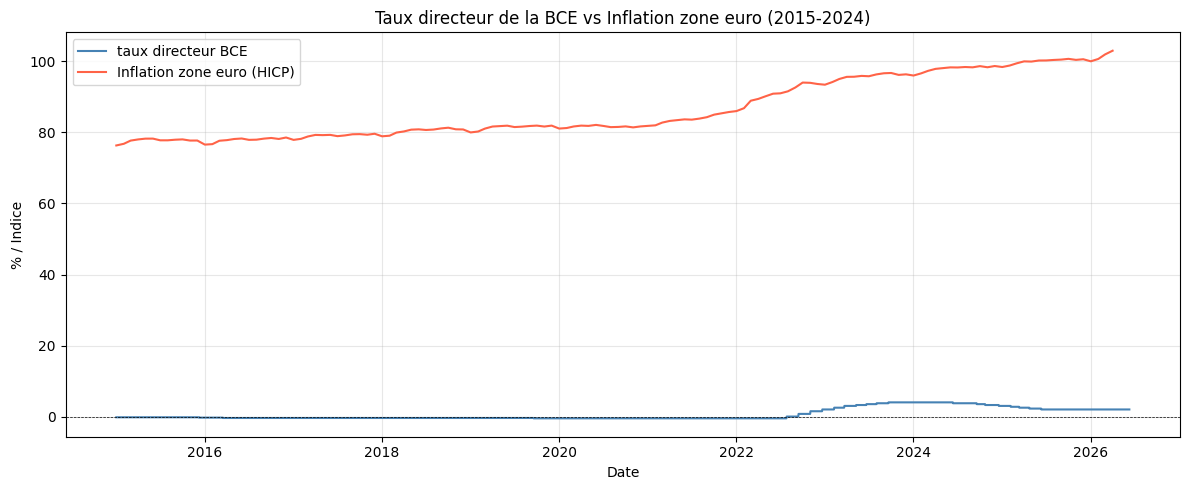

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(taux_bce["date"], taux_bce["value"], label="taux directeur BCE", color="steelblue")
plt.plot(inflation["date"], inflation["value"], label="Inflation zone euro (HICP)", color="tomato")
plt.axhline(0, color="black", linewidth=0.5, linestyle="--")
plt.title("Taux directeur de la BCE vs Inflation zone euro (2015-2024)")
plt.xlabel("Date")
plt.ylabel("% / Indice")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
inflation["value_pct"] = inflation["value"].pct_change(12)*100
inflation_clean = inflation.dropna()

print(inflation_clean.head())

         date  value  value_pct
12 2016-01-01  76.58   0.314383
13 2016-02-01  76.71  -0.130191
14 2016-03-01  77.67  -0.051473
15 2016-04-01  77.84  -0.256279
16 2016-05-01  78.16  -0.127779


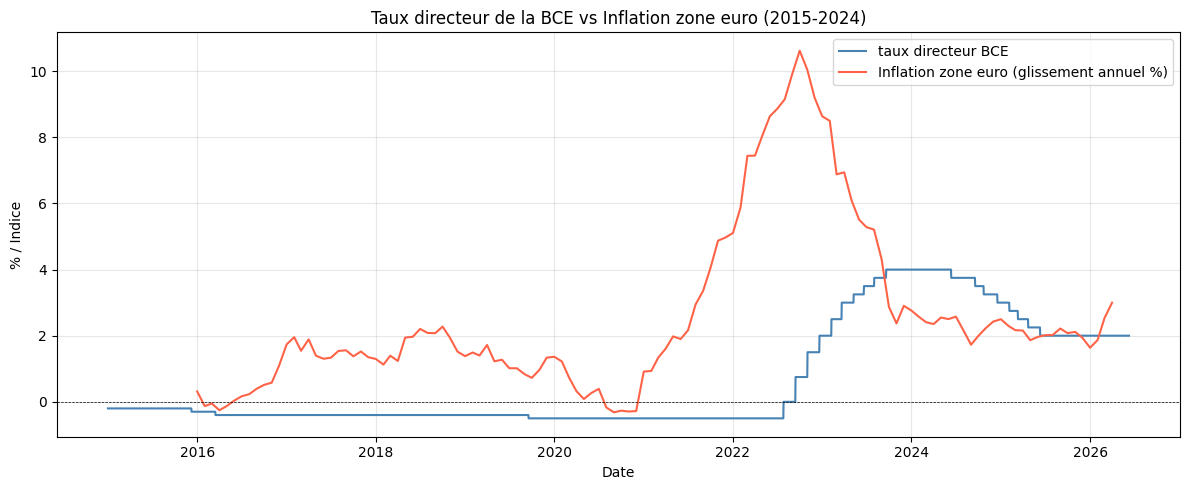

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(taux_bce["date"], taux_bce["value"], label="taux directeur BCE", color="steelblue")
plt.plot(inflation_clean["date"], inflation_clean["value_pct"], label="Inflation zone euro (glissement annuel %)", color="tomato")
plt.axhline(0, color="black", linewidth=0.5, linestyle="--")
plt.title("Taux directeur de la BCE vs Inflation zone euro (2015-2024)")
plt.xlabel("Date")
plt.ylabel("% / Indice")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
bce_mensuel = taux_bce.resample("MS", on="date").mean()
fusion = pd.merge(bce_mensuel, inflation_clean[["date", "value_pct"]], on="date")
correlation= fusion["value"].corr(fusion["value_pct"])
print(f"correlation BCE/Inflation : {correlation:.2f}")

correlation BCE/Inflation : 0.25


The correlation between the ECB key rate and eurozone inflation over 2015-2024 is 0.25(weak positive).This result is explained by the transmission lag of monetary policy: the ECB adjust its rates in reaction to observed inflation, not in anticipation. The periode from  2022 to 2023 clearly illustrates this delay.

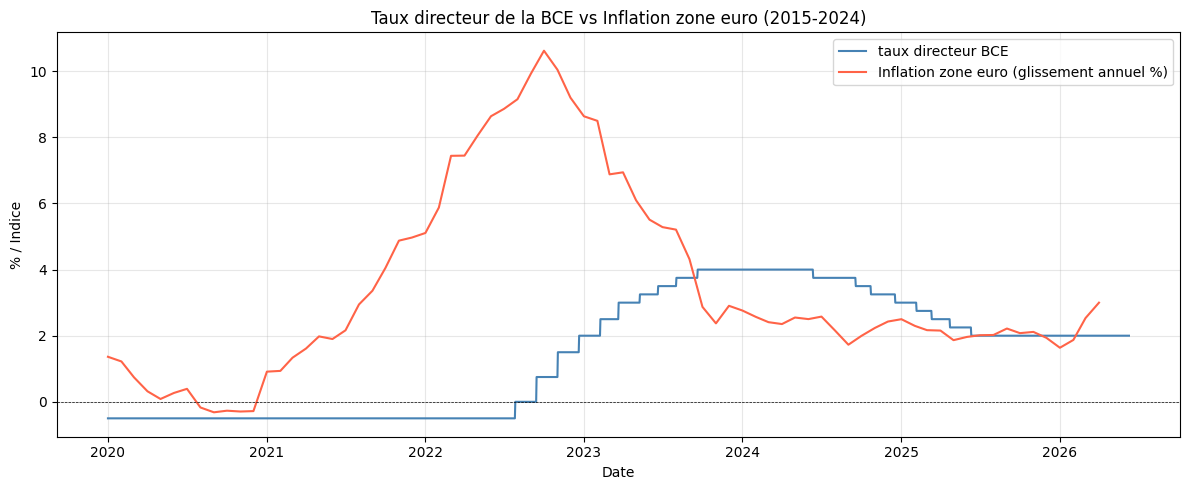

In [ ]:
mask_bce = (taux_bce["date"]>="2020-01-01")
mask_inf = (inflation_clean["date"]>="2020-01-01")

bce_zoom = taux_bce[mask_bce]
inf_zoom = inflation_clean[mask_inf]


plt.figure(figsize=(12, 5))
plt.plot(bce_zoom["date"], bce_zoom["value"], label="taux directeur BCE", color="steelblue")
plt.plot(inf_zoom["date"], inf_zoom["value_pct"], label="Inflation zone euro (glissement annuel %)", color="tomato")
plt.axhline(0, color="black", linewidth=0.5, linestyle="--")
plt.title("Taux directeur de la BCE vs Inflation zone euro (2015-2024)")
plt.xlabel("Date")
plt.ylabel("% / Indice")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

From 2020, the COVID-19 crisis triggered massive fiscal stimulus across the Eurozone. This exess liquidity, combined with supply chain disruptions and the 2022 energy shock, pushed inflation to his hightest level since the 1980s. the ECB maintained negative rates until july 2022, then executed the fastest thightening cycle in its history ( +450 basis points in 14 months ). The transmission lag is clearly visible on the chart above.